# 머신러닝 적용을 위한 데이터 처리 I
## 결측치 · 이상치 처리 실습 튜토리얼 (30문제)

**학습 목표**
- 결측치(Missing Values)의 개념을 이해하고 `isnull()`, `.loc[]`로 확인·처리한다.
- 시계열 보간법(Time-series Interpolation)으로 주가 데이터의 결측치를 복원한다.
- Boxplot과 IQR로 이상치를 탐색하고, 대체·구간화·제거 전략을 비교한다.
- 전처리 전후 시각화와 t-test로 통계적 변화를 해석한다.

**필수 실습 규칙**
1. 시각화: `fig, ax = plt.subplots()` 객체지향 API + `sns.*(..., ax=ax)`
2. Pandas: 인덱싱·필터링·값 할당은 반드시 `.loc[]`
3. 데이터: `seaborn` 내장 데이터셋 + 시계열 보간은 `yfinance` 주가 데이터
4. 처리 후: `subplots(1, 2)`로 전·후 비교 시각화 필수


---
## 0. 환경 설정 및 데이터 로드


### 문제 1. 필수 라이브러리 임포트 및 한글 폰트 설정

데이터 전처리·시각화·통계 검정에 필요한 라이브러리를 불러옵니다.
Colab/Linux 환경에서는 나눔고딕 폰트 설치 후 `matplotlib`에 적용합니다.


In [1]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

In [2]:
# ── 나눔고딕 폰트 설치 (Colab/Linux, 최초 1회) ─────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
font_dirs = ['/usr/share/fonts/truetype/nanum', '/Library/Fonts', '~/Library/Fonts']
for d in font_dirs:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

plt.rcParams.update({
    'font.family': 'NanumBarunGothic',
    'axes.unicode_minus': False,
    'figure.dpi': 110,
})
sns.set_theme(style='whitegrid', font='NanumBarunGothic',
              rc={'axes.unicode_minus': False})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('라이브러리 로드 완료')


라이브러리 로드 완료


### 문제 2. Seaborn 내장 데이터셋 로드 (titanic, penguins, tips)

머신러닝 전처리 실습의 기본 데이터로 `titanic`(결측치 다수), `penguins`(비교용), `tips`(이상치 실습)를 불러옵니다.


In [3]:
titanic = sns.load_dataset('titanic')
penguins = sns.load_dataset('penguins')
tips = sns.load_dataset('tips')

print('titanic shape:', titanic.shape)
print('penguins shape:', penguins.shape)
print('tips shape:', tips.shape)
titanic.head(3)


titanic shape: (891, 15)
penguins shape: (344, 7)
tips shape: (244, 7)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


### 문제 3. 결측치 확인의 기본 — `isnull().sum()`

각 컬럼별 결측치 개수를 집계합니다. 전처리 전 **반드시** 수행하는 1단계입니다.


In [4]:
missing_titanic = titanic.isnull().sum()
missing_titanic = missing_titanic[missing_titanic > 0].sort_values(ascending=False)
print('[titanic] 컬럼별 결측치 개수')
print(missing_titanic)


[titanic] 컬럼별 결측치 개수
deck           688
age            177
embarked         2
embark_town      2
dtype: int64


---
## 1. 결측치(Missing Values) 처리하기

**결측치**: 데이터 수집·입력 과정에서 값이 비어 있는 상태.  
**처리 전략 3가지**: (1) **수집** — 추가 데이터 확보, (2) **대체** — 통계값·보간법으로 채움, (3) **제거** — 행/열 삭제

### 1.1 일반 데이터 결측치 확인 및 기본 대체/제거


### 문제 4. 결측치 비율(%) 계산

개수뿐 아니라 **비율**을 함께 보면 '열 전체 삭제' vs '대체' 판단이 쉬워집니다.


In [5]:
n = len(titanic)
missing_pct = (titanic.isnull().sum() / n * 100).round(2)
missing_report = pd.DataFrame({'결측 수': titanic.isnull().sum(), '결측 비율(%)': missing_pct})
missing_report = missing_report.loc[missing_report['결측 수'] > 0]
missing_report.sort_values('결측 비율(%)', ascending=False)


,결측 수,결측 비율(%)
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


### 문제 5. 결측치 패턴 시각화 (heatmap)

`fig, ax = plt.subplots()`로 도화지를 만든 뒤, `sns.heatmap`을 `ax`에 매핑합니다.


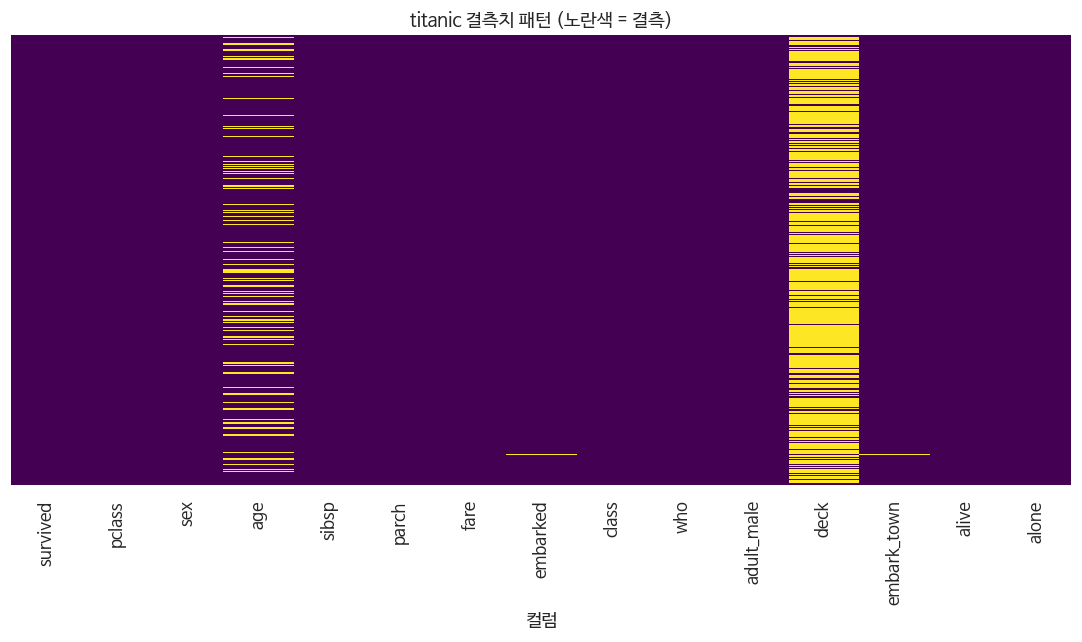

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False, ax=ax, cmap='viridis')
ax.set_title('titanic 결측치 패턴 (노란색 = 결측)')
ax.set_xlabel('컬럼')
plt.tight_layout()
plt.show()


### 문제 6. `.loc[]`로 결측치가 있는 행 조건 필터링

`age`가 결측인 승객만 추출해 실제 레코드를 확인합니다.


In [8]:
mask_age_null = titanic['age'].isnull()
rows_age_null = titanic.loc[mask_age_null, ['survived', 'pclass', 'sex', 'age', 'fare']]
print(f"age 결측 행 수: {len(rows_age_null)}")
rows_age_null.head()


age 결측 행 수: 177


,survived,pclass,sex,age,fare
5,0,3,male,NaN,8.4583
17,1,2,male,NaN,13.0000
19,1,3,female,NaN,7.2250
26,0,3,male,NaN,7.2250
28,1,3,female,NaN,7.8792


### 문제 7. 결측 비율이 높은 열 제거 — `deck` 열

`deck`은 결측 비율이 약 77%로, 대체하기보다 **열 제거**가 합리적입니다.  
원본 보존을 위해 `df` 복사본을 만들고 `.loc`로 필요한 열만 유지합니다.


In [9]:
df = titanic.copy()
cols_to_keep = [c for c in df.columns if c != 'deck']
df = df.loc[:, cols_to_keep]
print("'deck' 열 제거 후 shape:", df.shape)
print("deck 결측:", df.columns.str.contains('deck').any())


'deck' 열 제거 후 shape: (891, 14)
deck 결측: False


### 문제 8. `.loc[]`로 특정 열 결측 행 제거 (부분 삭제)

`embarked`, `embark_town`은 결측이 2건뿐이므로 **행 삭제**가 적합합니다.


In [10]:
before_len = len(df)
mask_drop = df['embarked'].isnull() | df['embark_town'].isnull()
df = df.loc[~mask_drop].copy()
print(f"삭제된 행: {before_len - len(df)}건 → 현재 {len(df)}건")


삭제된 행: 2건 → 현재 889건


### 문제 9. 중앙값(Median)으로 `age` 결측 대체 — `.loc[]` 할당

나이는 분포가 치우칠 수 있어 **평균보다 중앙값**이 이상치에 덜 민감합니다.


In [11]:
age_median = df['age'].median()
mask_age = df['age'].isnull()
df.loc[mask_age, 'age'] = age_median
print(f"age 중앙값 대체 완료 (중앙값={age_median:.1f})")
print("age 남은 결측:", df['age'].isnull().sum())


age 중앙값 대체 완료 (중앙값=28.0)
age 남은 결측: 0


### 문제 10. 그룹별 중앙값으로 `fare` 결측 대체

객실 등급(`pclass`)별로 요금 분포가 다르므로, **그룹 중앙값** 대체가 더 정교합니다.


In [12]:
for pclass_val in df['pclass'].unique():
    mask = (df['pclass'] == pclass_val) & (df['fare'].isnull())
    grp_median = df.loc[df['pclass'] == pclass_val, 'fare'].median()
    df.loc[mask, 'fare'] = grp_median
print("fare 남은 결측:", df['fare'].isnull().sum())


fare 남은 결측: 0


### 문제 11. penguins 데이터 — 인위적 결측치 생성 및 전략 비교

실험을 위해 `body_mass_g` 일부를 NaN으로 만든 뒤, 평균·중앙값 대체 결과를 비교합니다.


In [13]:
pg = penguins.dropna(subset=['body_mass_g']).copy()
np.random.seed(RANDOM_STATE)
idx_sample = pg.sample(30, random_state=RANDOM_STATE).index
pg.loc[idx_sample, 'body_mass_g'] = np.nan

mean_fill = pg['body_mass_g'].fillna(pg['body_mass_g'].mean())
median_fill = pg['body_mass_g'].fillna(pg['body_mass_g'].median())
print('원본 평균:', penguins['body_mass_g'].mean().round(1))
print('평균 대체 평균:', mean_fill.mean().round(1))
print('중앙값 대체 평균:', median_fill.mean().round(1))


원본 평균: 4201.8
평균 대체 평균: 4211.0
중앙값 대체 평균: 4196.9


### 문제 12. `ffill` / `bfill` — 순서가 있는 데이터의 전·후 값 채우기

범주형 또는 시계열에서 **앞/뒤 관측값**으로 채우는 방법입니다.


In [14]:
ts_demo = pd.DataFrame({'value': [10, np.nan, np.nan, 13, 14, np.nan, 16]})
ts_demo['ffill'] = ts_demo['value'].ffill()
ts_demo['bfill'] = ts_demo['value'].bfill()
ts_demo


,value,ffill,bfill
0,10.0,10.0,10.0
1,NaN,10.0,13.0
2,NaN,10.0,13.0
3,13.0,13.0,13.0
4,14.0,14.0,14.0
5,NaN,14.0,16.0
6,16.0,16.0,16.0


### 문제 13. 결측치 처리 전·후 시각화 비교 (age, subplots 1×2)

**필수**: `fig, axes = plt.subplots(1, 2)`로 처리 전(`titanic`)과 후(`df`) 분포를 나란히 비교합니다.


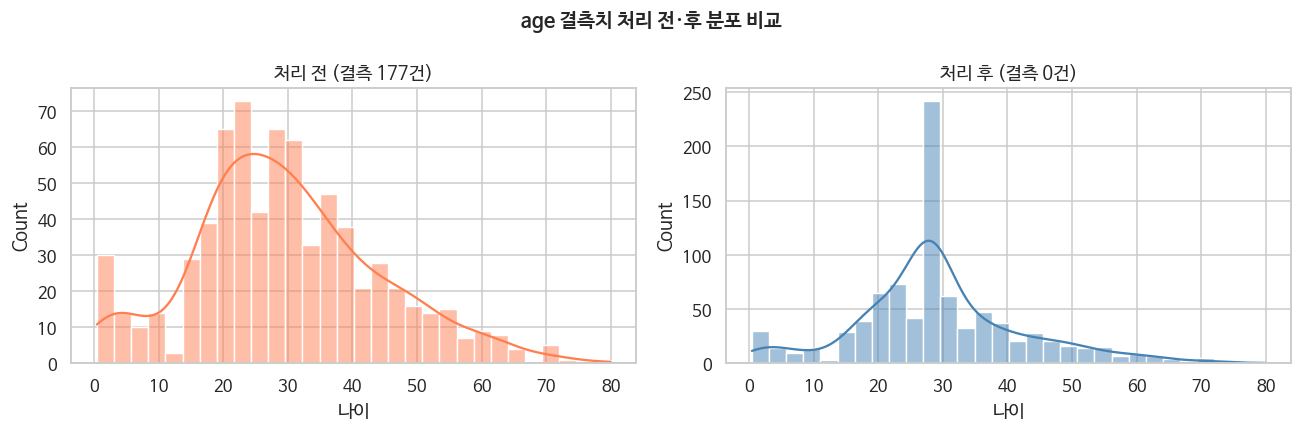

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('age 결측치 처리 전·후 분포 비교', fontsize=13, fontweight='bold')

sns.histplot(data=titanic, x='age', kde=True, ax=axes[0], color='coral', bins=30)
axes[0].set_title(f'처리 전 (결측 {titanic["age"].isnull().sum()}건)')
axes[0].set_xlabel('나이')

sns.histplot(data=df, x='age', kde=True, ax=axes[1], color='steelblue', bins=30)
axes[1].set_title(f'처리 후 (결측 {df["age"].isnull().sum()}건)')
axes[1].set_xlabel('나이')

plt.tight_layout()
plt.show()


### 1.2 시계열 데이터 결측치 처리 (주식 데이터 + Time-series 보간법)


### 문제 14. `yfinance`로 주가 데이터 다운로드

시계열 보간법 실습을 위해 특정 기업(예: Apple)의 종가(`Close`) 시계열을 가져옵니다.


In [16]:
# yfinance 미설치 시: pip install yfinance
!pip install -q yfinance

import yfinance as yf

ticker = 'AAPL'
stock = yf.download(ticker, start='2023-01-01', end='2024-01-01', progress=False)
if isinstance(stock.columns, pd.MultiIndex):
    stock.columns = stock.columns.get_level_values(0)
stock = stock[['Close']].copy()
stock.index.name = 'Date'
print(stock.head())
print('관측치 수:', len(stock))


Price            Close
Date                  
2023-01-03  122.982727
2023-01-04  124.251183
2023-01-05  122.933563
2023-01-06  127.456802
2023-01-09  127.977928
관측치 수: 250


### 문제 15. 주가 데이터에 인위적 결측치 삽입

랜덤하게 15개 거래일의 종가를 NaN으로 만들어 보간 실습 환경을 구성합니다.


In [17]:
stock_miss = stock.copy()
rng = np.random.default_rng(RANDOM_STATE)
miss_idx = rng.choice(stock_miss.index, size=15, replace=False)
stock_miss.loc[miss_idx, 'Close'] = np.nan
print('삽입된 결측치:', stock_miss['Close'].isnull().sum())
stock_miss.loc[miss_idx[:5]]


삽입된 결측치: 15


Price,Close
Date,
2023-02-02,NaN
2023-02-06,NaN
2023-08-16,NaN
2023-10-04,NaN
2023-03-15,NaN


### 문제 16. 선형 보간법 — `interpolate(method='linear')`

인접 두 시점 사이를 **직선**으로 연결해 결측값을 추정합니다.


In [18]:
stock_linear = stock_miss.copy()
stock_linear['Close_linear'] = stock_linear['Close'].interpolate(method='linear')
print('linear 보간 후 결측:', stock_linear['Close_linear'].isnull().sum())


linear 보간 후 결측: 0


### 문제 17. 시계열 보간법 — `interpolate(method='time')`

날짜 간 **실제 시간 간격**을 반영해 보간합니다. 주말·휴장일이 있는 금융 데이터에 적합합니다.


In [19]:
stock_time = stock_miss.copy()
stock_time['Close_time'] = stock_time['Close'].interpolate(method='time')
print('time 보간 후 결측:', stock_time['Close_time'].isnull().sum())


time 보간 후 결측: 0


### 문제 18. 다항·스플라인 보간법 비교 (method='polynomial', 'spline')

단기 급변 구간에서는 고차 보간이 더 부드러운 곡선을 만들 수 있습니다. (차수/order 주의)


In [20]:
stock_poly = stock_miss.copy()
stock_poly['Close_poly'] = stock_poly['Close'].interpolate(method='polynomial', order=2)
stock_poly['Close_spline'] = stock_poly['Close'].interpolate(method='spline', order=2)
stock_poly.loc[miss_idx[:3], ['Close', 'Close_poly', 'Close_spline']]


Price,Close,Close_poly,Close_spline
Date,,,
2023-02-02,NaN,148.774470,149.750961
2023-02-06,NaN,153.918005,152.150988
2023-08-16,NaN,173.032069,173.332870


### 문제 19. 시계열 결측 처리 전·후 시각화 (subplots 1×2)

원본 종가와 `method='time'` 보간 결과를 나란히 비교합니다.


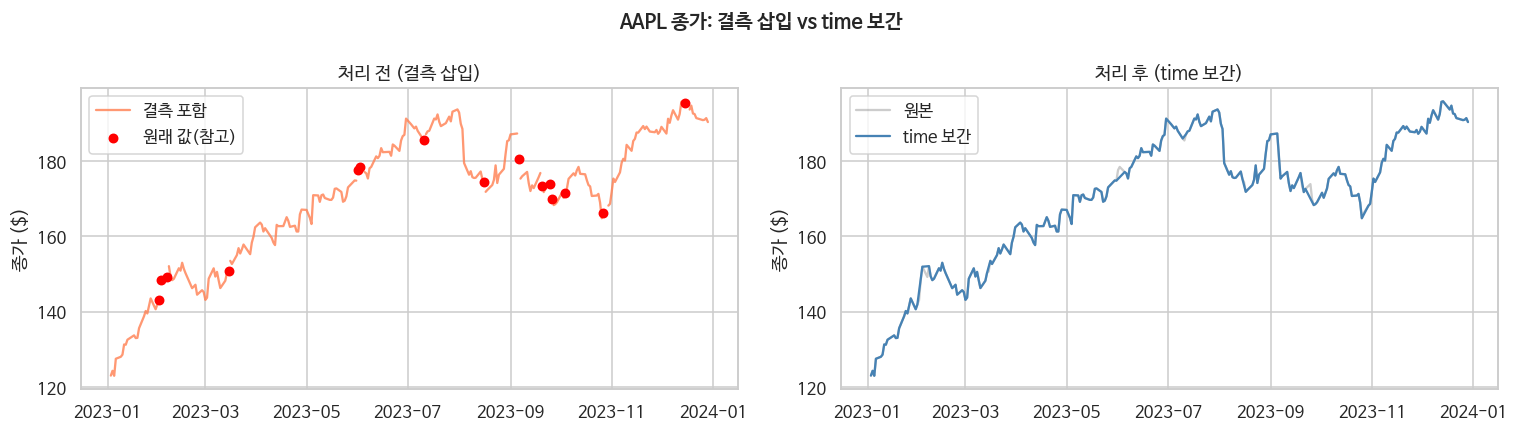

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'{ticker} 종가: 결측 삽입 vs time 보간', fontsize=13, fontweight='bold')

ref_vals = stock.loc[miss_idx, 'Close']
axes[0].plot(stock_miss.index, stock_miss['Close'], color='coral', alpha=0.8, label='결측 포함')
axes[0].scatter(miss_idx, ref_vals, color='red', s=30, zorder=5, label='원래 값(참고)')
axes[0].set_title('처리 전 (결측 삽입)')
axes[0].set_ylabel('종가 ($)')
axes[0].legend()

axes[1].plot(stock.index, stock['Close'], color='gray', alpha=0.4, label='원본')
axes[1].plot(stock_time.index, stock_time['Close_time'], color='steelblue', label='time 보간')
axes[1].set_title('처리 후 (time 보간)')
axes[1].set_ylabel('종가 ($)')
axes[1].legend()

plt.tight_layout()
plt.show()


### 문제 20. 보간 후 잔여 결측 제거 및 최종 검증

시계열 **양 끝**은 보간 불가능한 경우가 있어, `.loc[]`로 유효 구간만 남깁니다.


In [22]:
stock_final = stock_time.copy()
stock_final['Close'] = stock_final['Close_time']
stock_final = stock_final.loc[stock_final['Close'].notnull(), ['Close']]
print('최종 결측:', stock_final['Close'].isnull().sum())
print('최종 관측치:', len(stock_final))


최종 결측: 0
최종 관측치: 250


---
## 2. 이상치(Outliers) 처리하기

**이상치**: 다른 관측값과 현저히 동떨어진 값. 수집 오류 또는 극단적 사례일 수 있습니다.  
**처리 방법**: (1) **통계값 대체**(Winsorizing/clip), (2) **구간화·변수화**, (3) **제거**

### 2.1 Boxplot을 통한 이상치 탐색


### 문제 21. IQR(사분위수 범위)로 이상치 경계 계산 — tips `total_bill`

$Q1 - 1.5 \times IQR$ ~ $Q3 + 1.5 \times IQR$ 범위를 벗어나면 Boxplot에서 이상치로 표시됩니다.


In [23]:
df_tips = tips.copy()
Q1 = df_tips['total_bill'].quantile(0.25)
Q3 = df_tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'하한={lower:.2f}, 상한={upper:.2f}')
mask_outlier = (df_tips['total_bill'] < lower) | (df_tips['total_bill'] > upper)
print('이상치 개수:', mask_outlier.sum())


Q1=13.35, Q3=24.13, IQR=10.78
하한=-2.82, 상한=40.30
이상치 개수: 9


### 문제 22. Boxplot 시각화 — `fig, ax = plt.subplots()` + `sns.boxplot`

객체지향 API로 Boxplot을 그려 이상치(점)를 확인합니다.


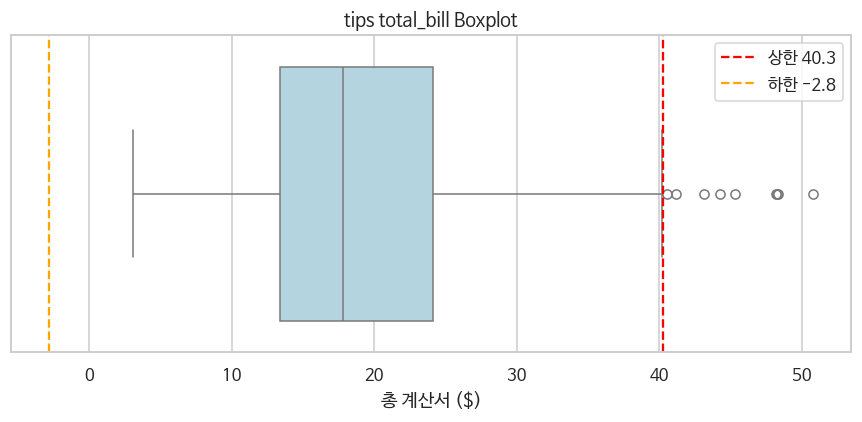

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df_tips, x='total_bill', ax=ax, color='lightblue')
ax.axvline(upper, color='red', linestyle='--', label=f'상한 {upper:.1f}')
ax.axvline(lower, color='orange', linestyle='--', label=f'하한 {lower:.1f}')
ax.set_title('tips total_bill Boxplot')
ax.set_xlabel('총 계산서 ($)')
ax.legend()
plt.tight_layout()
plt.show()


### 문제 23. `.loc[]`로 이상치 행 추출 및 확인

조건 마스크로 이상치 레코드만 선택합니다.


In [25]:
outliers = df_tips.loc[mask_outlier, ['total_bill', 'tip', 'size']]
print(f'이상치 {len(outliers)}건')
outliers.head(10)


이상치 9건


,total_bill,tip,size
59,48.27,6.73,4
102,44.30,2.50,3
142,41.19,5.00,5
156,48.17,5.00,6
170,50.81,10.00,3
182,45.35,3.50,3
184,40.55,3.00,2
197,43.11,5.00,4
212,48.33,9.00,4


### 2.2 이상치 처리 (통계값 대체 · 구간화 · 제거)


### 문제 24. Winsorizing — `.loc[]` + `clip()`으로 상·하한 대체

이상치를 **삭제하지 않고** 경계값으로 잘라 데이터 손실을 줄입니다.


In [26]:
df_clip = df_tips.copy()
df_clip.loc[:, 'total_bill_clean'] = df_clip['total_bill'].clip(lower=lower, upper=upper)
print('처리 전 max:', df_tips['total_bill'].max())
print('처리 후 max:', df_clip['total_bill_clean'].max())


처리 전 max: 50.81
처리 후 max: 40.29749999999999


### 문제 25. 구간화(Binning) — `pd.cut()` + `.loc[]` 할당

연속형 `total_bill`을 구간 레이블 범주로 변환해 **이상치의 영향을 완화**합니다.


In [27]:
df_bin = df_tips.copy()
df_bin.loc[:, 'bill_bin'] = pd.cut(
    df_bin['total_bill'],
    bins=[0, 10, 20, 30, 50, 100],
    labels=['~10', '10~20', '20~30', '30~50', '50~']
)
df_bin.loc[:, 'bill_bin'].value_counts().sort_index()


,count
bill_bin,
~10,17
10~20,130
20~30,65
30~50,31
50~,1


### 문제 26. `.loc[]`로 이상치 행 제거

소규모 데이터(244건)에서는 삭제 시 손실이 크므로, **Winsorizing과 비교**하며 선택합니다.


In [28]:
df_drop = df_tips.loc[~mask_outlier].copy()
print(f'제거 전: {len(df_tips)}건 → 제거 후: {len(df_drop)}건 (삭제 {mask_outlier.sum()}건)')


제거 전: 244건 → 제거 후: 235건 (삭제 9건)


### 2.3 이상치 처리 전·후 시각화 비교


### 문제 27. Boxplot 전·후 비교 (subplots 1×2)


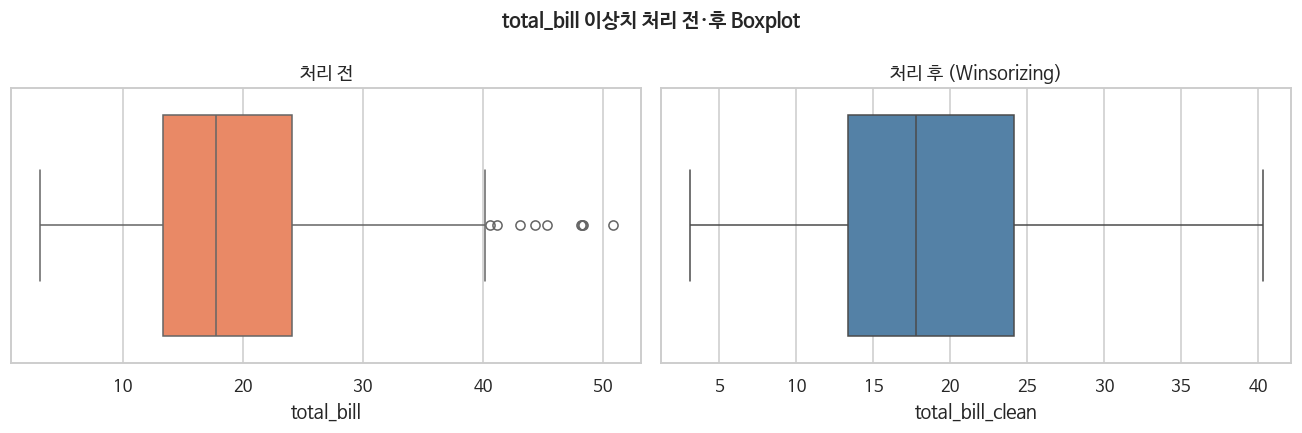

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('total_bill 이상치 처리 전·후 Boxplot', fontsize=13, fontweight='bold')

sns.boxplot(data=df_tips, x='total_bill', ax=axes[0], color='coral')
axes[0].set_title('처리 전')

sns.boxplot(data=df_clip, x='total_bill_clean', ax=axes[1], color='steelblue')
axes[1].set_title('처리 후 (Winsorizing)')

plt.tight_layout()
plt.show()


### 문제 28. Histogram 전·후 비교 (subplots 1×2)


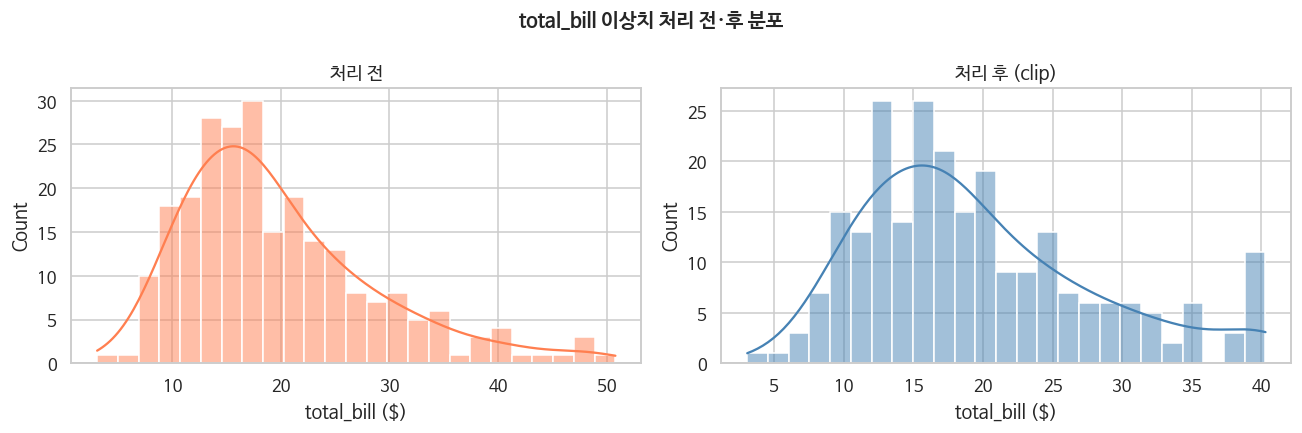

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('total_bill 이상치 처리 전·후 분포', fontsize=13, fontweight='bold')

sns.histplot(data=df_tips, x='total_bill', kde=True, ax=axes[0], color='coral', bins=25)
axes[0].set_title('처리 전')
axes[0].set_xlabel('total_bill ($)')

sns.histplot(data=df_clip, x='total_bill_clean', kde=True, ax=axes[1], color='steelblue', bins=25)
axes[1].set_title('처리 후 (clip)')
axes[1].set_xlabel('total_bill ($)')

plt.tight_layout()
plt.show()


---
## 3. [심화] 전처리 유무에 따른 통계 검정(t-test) 결과 비교

독립표본 t-test로 **두 그룹 평균 차이**가 통계적으로 유의한지(p-value) 확인합니다.  
전처리(결측·이상치 처리)가 **통계적 결론**에 미치는 영향을 비교합니다.


### 문제 29. titanic — age 결측·이상치 처리 **전** 생존 그룹 t-test

`age`가 있는 승객만 대상으로, 생존(1) vs 사망(0) 그룹의 나이 평균 차이를 검정합니다.


In [31]:
t_pre = titanic.dropna(subset=['age']).copy()
# IQR 이상치(age) 제거 전
Q1_a = t_pre['age'].quantile(0.25)
Q3_a = t_pre['age'].quantile(0.75)
IQR_a = Q3_a - Q1_a
lo_a, hi_a = Q1_a - 1.5 * IQR_a, Q3_a + 1.5 * IQR_a

group_surv_pre = t_pre.loc[t_pre['survived'] == 1, 'age']
group_dead_pre = t_pre.loc[t_pre['survived'] == 0, 'age']
t_stat_pre, p_pre = stats.ttest_ind(group_surv_pre, group_dead_pre, equal_var=False)

print('[처리 전] 생존 vs 사망 age t-test')
print(f'  생존 평균: {group_surv_pre.mean():.2f}, 사망 평균: {group_dead_pre.mean():.2f}')
print(f'  t-statistic: {t_stat_pre:.4f}, p-value: {p_pre:.4e}')
print(f'  유의수준 0.05 기준: {"유의함" if p_pre < 0.05 else "유의하지 않음"}')


[처리 전] 생존 vs 사망 age t-test
  생존 평균: 28.34, 사망 평균: 30.63
  t-statistic: -2.0460, p-value: 4.1190e-02
  유의수준 0.05 기준: 유의함


### 문제 30. 결측 대체 + age 이상치 Winsorizing **후** t-test 및 p-value 비교

`df`(결측 처리 완료)에서 age IQR Winsorizing 후 동일 검정을 반복하고, p-value 변화를 해석합니다.


In [32]:
t_post = df.copy()
lo_p, hi_p = lo_a, hi_a
t_post.loc[t_post['age'] < lo_p, 'age'] = lo_p
t_post.loc[t_post['age'] > hi_p, 'age'] = hi_p

group_surv_post = t_post.loc[t_post['survived'] == 1, 'age']
group_dead_post = t_post.loc[t_post['survived'] == 0, 'age']
t_stat_post, p_post = stats.ttest_ind(group_surv_post, group_dead_post, equal_var=False)

print('[처리 후] 생존 vs 사망 age t-test')
print(f'  생존 평균: {group_surv_post.mean():.2f}, 사망 평균: {group_dead_post.mean():.2f}')
print(f'  t-statistic: {t_stat_post:.4f}, p-value: {p_post:.4e}')
print(f'  유의수준 0.05 기준: {"유의함" if p_post < 0.05 else "유의하지 않음"}')
print()
print('--- p-value 비교 ---')
print(f'  처리 전 p-value: {p_pre:.4e}')
print(f'  처리 후 p-value: {p_post:.4e}')
print('  해석: 전처리 방식(결측 대체·이상치 clip)에 따라')
print('        검정 통계량과 p-value가 달라질 수 있으므로,')
print('        분석 보고서에는 전처리 절차를 함께 명시해야 합니다.')


[처리 후] 생존 vs 사망 age t-test
  생존 평균: 28.12, 사망 평균: 29.96
  t-statistic: -2.0381, p-value: 4.1936e-02
  유의수준 0.05 기준: 유의함

--- p-value 비교 ---
  처리 전 p-value: 4.1190e-02
  처리 후 p-value: 4.1936e-02
  해석: 전처리 방식(결측 대체·이상치 clip)에 따라
        검정 통계량과 p-value가 달라질 수 있으므로,
        분석 보고서에는 전처리 절차를 함께 명시해야 합니다.


---
## 정리

| 단계 | 핵심 기법 | 주요 함수/문법 |
|------|----------|----------------|
| 결측 확인 | 개수·비율·패턴 | `isnull().sum()`, `heatmap` |
| 결측 제거 | 행/열 삭제 | `.loc[~mask]`, 열 선택 |
| 결측 대체 | 중앙값·그룹값·ffill | `.loc[mask, col] = value` |
| 시계열 보간 | linear / time / spline | `interpolate(method='time')` |
| 이상치 탐색 | IQR, Boxplot | `quantile`, `sns.boxplot(..., ax=ax)` |
| 이상치 처리 | clip, binning, 제거 | `.clip()`, `pd.cut()`, `.loc[~mask]` |
| 심화 | t-test | `scipy.stats.ttest_ind` |

**30문제 완료** — 각 문제의 코드를 순서대로 실행하며 실습하세요.
